<a href="https://colab.research.google.com/github/esiba07/cyclistic-bike-share-analysis/blob/main/Copy_of_Cyclistic_Bike_Share_Case_Study_ipynb_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cyclistic Bike-Share Case Study
## Phase 1: Ask

### Business Task
Analyze Cyclistic's historical bike trip data to identify behavioral differences between casual riders and annual members. The primary goal is to provide data-backed insights to guide marketing strategies aimed at converting casual riders into annual members.

### Key Questions
* **Primary Question:** How do annual members and casual riders use Cyclistic bikes differently?

### Key Stakeholders
* **Lily Moreno:** Director of Marketing
* **Cyclistic Marketing Analytics Team:** Data analytics peers
* **Cyclistic Executive Team:** Decision-makers approving marketing strategy

In [ ]:
# Import required Python libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns when viewing dataframes
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


## Phase 2: Prepare

### Data Source Information
* **Source:** Historical public trip dataset provided by Motivate International Inc. / Divvy ([Data Index Link](https://divvy-tripdata.s3.amazonaws.com/index.html)).
* **Coverage:** 12 months of historical bike trip records.
* **Organization:** Data is provided as monthly CSV files containing trip details such as ride ID, bike type, start/end timestamps, station names/IDs, location coordinates, and rider type (`member` vs `casual`).

### Data Credibility & Verification (ROCCC)
* **Reliable:** High integrity; generated directly by the bike-share logging system.
* **Original:** Primary dataset provided by the operating company.
* **Comprehensive:** Contains complete trip records across all user types for the selected period.
* **Current:** Historical data updated regularly on a monthly schedule.
* **Cited:** Public data licensed under the official Divvy Data License Agreement.

### Data Limitations & Privacy
* **Privacy:** Personally Identifiable Information (PII) is excluded. We cannot link pass purchases to individual riders or trace specific customer IDs.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import pandas and load the 2019 Q1 and 2020 Q1 datasets
import pandas as pd

q1_2019 = pd.read_csv('/content/drive/MyDrive/Cyclistic_Data/Divvy_Trips_2019_Q1.csv')
q1_2020 = pd.read_csv('/content/drive/MyDrive/Cyclistic_Data/Divvy_Trips_2020_Q1.csv')

print("2019 Q1 Shape:", q1_2019.shape)
print("2020 Q1 Shape:", q1_2020.shape)

2019 Q1 Shape: (365069, 12)
2020 Q1 Shape: (426887, 13)


In [ ]:
# Print column names for both datasets
print("--- 2019 Columns ---")
print(q1_2019.columns.tolist())

print("\n--- 2020 Columns ---")
print(q1_2020.columns.tolist())

--- 2019 Columns ---
['trip_id', 'start_time', 'end_time', 'bikeid', 'tripduration', 'from_station_id', 'from_station_name', 'to_station_id', 'to_station_name', 'usertype', 'gender', 'birthyear']

--- 2020 Columns ---
['ride_id', 'rideable_type', 'started_at', 'ended_at', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng', 'member_casual']


In [ ]:
# Rename 2019 columns to match 2020 column schema
q1_2019 = q1_2019.rename(columns={
    'trip_id': 'ride_id',
    'start_time': 'started_at',
    'end_time': 'ended_at',
    'from_station_id': 'start_station_id',
    'from_station_name': 'start_station_name',
    'to_station_id': 'end_station_id',
    'to_station_name': 'end_station_name',
    'usertype': 'member_casual'
})

# Verify that column names match now
print("Updated 2019 Columns:")
print(q1_2019.columns.tolist())

Updated 2019 Columns:
['ride_id', 'started_at', 'ended_at', 'bikeid', 'tripduration', 'start_station_id', 'start_station_name', 'end_station_id', 'end_station_name', 'member_casual', 'gender', 'birthyear']


In [ ]:
# Check values before remapping
print("2019 user types before:", q1_2019['member_casual'].value_counts().to_dict())

# Map 2019 labels to 2020 format
q1_2019['member_casual'] = q1_2019['member_casual'].replace({
    'Subscriber': 'member',
    'Customer': 'casual'
})

# Check values after remapping
print("2019 user types after:", q1_2019['member_casual'].value_counts().to_dict())

2019 user types before: {'Subscriber': 341906, 'Customer': 23163}
2019 user types after: {'member': 341906, 'casual': 23163}


In [ ]:
# List of standard columns present in both datasets
columns_to_keep = [
    'ride_id', 'started_at', 'ended_at',
    'start_station_name', 'start_station_id',
    'end_station_name', 'end_station_id',
    'member_casual'
]

# Keep standard columns
q1_2019_clean = q1_2019[columns_to_keep]
q1_2020_clean = q1_2020[columns_to_keep]

# Combine (stack) both datasets vertically into a single DataFrame
all_trips = pd.concat([q1_2019_clean, q1_2020_clean], ignore_index=True)

print("Combined DataFrame Shape:", all_trips.shape)
all_trips.head()

Combined DataFrame Shape: (791956, 8)


,ride_id,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,member_casual
0,21742443,2019-01-01 0:04:37,2019-01-01 0:11:07,Wabash Ave & Grand Ave,199,Milwaukee Ave & Grand Ave,84.0,member
1,21742444,2019-01-01 0:08:13,2019-01-01 0:15:34,State St & Randolph St,44,Dearborn St & Van Buren St (*),624.0,member
2,21742445,2019-01-01 0:13:23,2019-01-01 0:27:12,Racine Ave & 18th St,15,Western Ave & Fillmore St (*),644.0,member
3,21742446,2019-01-01 0:13:45,2019-01-01 0:43:28,California Ave & Milwaukee Ave,123,Clark St & Elm St,176.0,member
4,21742447,2019-01-01 0:14:52,2019-01-01 0:20:56,Mies van der Rohe Way & Chicago Ave,173,Streeter Dr & Grand Ave,35.0,member


In [ ]:
# Convert started_at and ended_at to datetime objects
all_trips['started_at'] = pd.to_datetime(all_trips['started_at'])
all_trips['ended_at'] = pd.to_datetime(all_trips['ended_at'])

# Calculate ride_length in minutes
all_trips['ride_length_min'] = (all_trips['ended_at'] - all_trips['started_at']).dt.total_seconds() / 60

# Extract day of week (e.g., Sunday, Monday) and month
all_trips['day_of_week'] = all_trips['started_at'].dt.day_name()
all_trips['month'] = all_trips['started_at'].dt.month_name()
all_trips['year'] = all_trips['started_at'].dt.year

all_trips[['started_at', 'ended_at', 'ride_length_min', 'day_of_week']].head()

,started_at,ended_at,ride_length_min,day_of_week
0,2019-01-01 00:04:37,2019-01-01 00:11:07,6.500000,Tuesday
1,2019-01-01 00:08:13,2019-01-01 00:15:34,7.350000,Tuesday
2,2019-01-01 00:13:23,2019-01-01 00:27:12,13.816667,Tuesday
3,2019-01-01 00:13:45,2019-01-01 00:43:28,29.716667,Tuesday
4,2019-01-01 00:14:52,2019-01-01 00:20:56,6.066667,Tuesday


In [ ]:
# Check count before cleaning
total_before = len(all_trips)

# Keep only rides with duration greater than 0 minutes
all_trips_v2 = all_trips[all_trips['ride_length_min'] > 0].copy()

total_after = len(all_trips_v2)
print(f"Removed {total_before - total_after} invalid rides.")
print(f"Cleaned dataset count: {total_after} rows")

Removed 210 invalid rides.
Cleaned dataset count: 791746 rows


## Phase 4: Analyze

### Analysis Goals
* Compare total rides between casual riders and annual members.
* Compare average and median ride lengths between user types.
* Identify usage patterns by day of the week and month.

In [ ]:
# Group by member_casual and calculate key summary statistics
summary_stats = all_trips_v2.groupby('member_casual')['ride_length_min'].agg(
    total_rides='count',
    mean_ride_length='mean',
    median_ride_length='median',
    min_ride_length='min',
    max_ride_length='max'
).reset_index()

summary_stats

,member_casual,total_rides,mean_ride_length,median_ride_length,min_ride_length,max_ride_length
0,casual,71433,85.091464,22.066667,0.016667,177200.366667
1,member,720313,13.254188,8.466667,0.016667,101607.133333


In [ ]:
# Define order for days of the week
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Group by user type and day of week
weekly_summary = all_trips_v2.groupby(['member_casual', 'day_of_week'])['ride_length_min'].agg(
    number_of_rides='count',
    avg_duration_min='mean'
).reindex(days_order, level='day_of_week').reset_index()

weekly_summary

,member_casual,day_of_week,number_of_rides,avg_duration_min
0,casual,Monday,6694,66.161246
1,casual,Tuesday,7972,69.730156
2,casual,Wednesday,8363,68.668104
3,casual,Thursday,7771,129.553770
4,casual,Friday,8508,95.609577
5,casual,Saturday,13473,82.512847
6,casual,Sunday,18652,84.355073
7,member,Monday,110430,13.705187
8,member,Tuesday,127974,12.824027
9,member,Wednesday,121903,11.866302


In [ ]:
# Top 5 starting stations for casual riders
print("--- Top 5 Start Stations: Casual Riders ---")
print(all_trips_v2[all_trips_v2['member_casual'] == 'casual']['start_station_name'].value_counts().head(5))

# Top 5 starting stations for annual members
print("\n--- Top 5 Start Stations: Annual Members ---")
print(all_trips_v2[all_trips_v2['member_casual'] == 'member']['start_station_name'].value_counts().head(5))

--- Top 5 Start Stations: Casual Riders ---
start_station_name
HQ QR                        3556
Streeter Dr & Grand Ave      2749
Lake Shore Dr & Monroe St    2732
Shedd Aquarium               1832
Millennium Park              1406
Name: count, dtype: int64

--- Top 5 Start Stations: Annual Members ---
start_station_name
Canal St & Adams St             13799
Clinton St & Washington Blvd    13434
Clinton St & Madison St         12891
Kingsbury St & Kinzie St         8720
Columbus Dr & Randolph St        8515
Name: count, dtype: int64


/tmp/ipykernel_1197/2417631947.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='member_casual', y='mean_ride_length', data=summary_stats, palette='viridis')


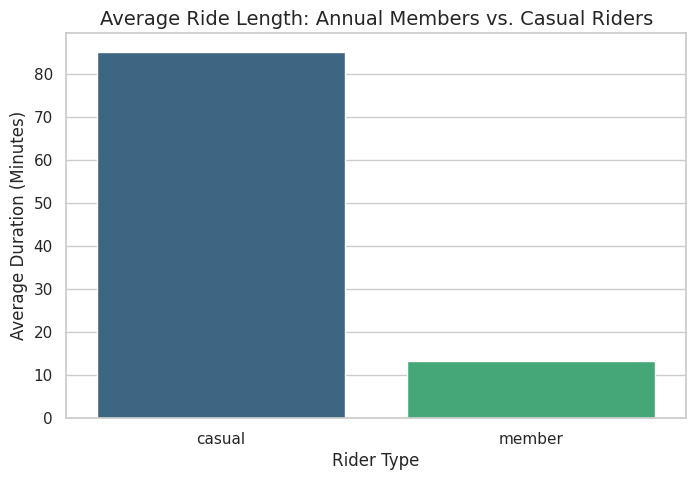

In [ ]:
# Set visual style
sns.set_theme(style="whitegrid")

# Create a bar chart for average ride length
plt.figure(figsize=(8, 5))
sns.barplot(x='member_casual', y='mean_ride_length', data=summary_stats, palette='viridis')
plt.title('Average Ride Length: Annual Members vs. Casual Riders', fontsize=14)
plt.xlabel('Rider Type', fontsize=12)
plt.ylabel('Average Duration (Minutes)', fontsize=12)
plt.show()

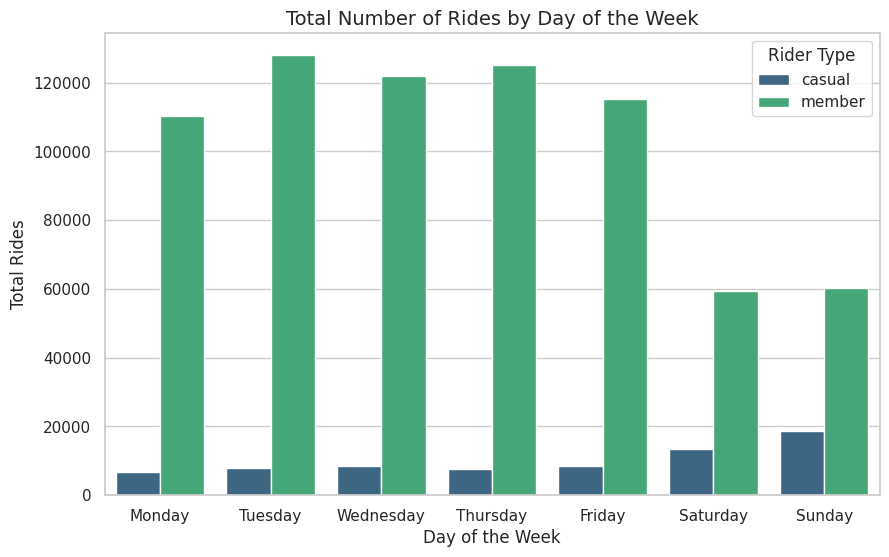

In [ ]:
# Create a clustered bar chart for rides by day of the week
plt.figure(figsize=(10, 6))
sns.barplot(x='day_of_week', y='number_of_rides', hue='member_casual', data=weekly_summary, palette='viridis')
plt.title('Total Number of Rides by Day of the Week', fontsize=14)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Total Rides', fontsize=12)
plt.legend(title='Rider Type')
plt.show()

## Phase 6: Act

### Key Conclusions
1. **Casual riders ride for leisure:** Their average ride length is significantly higher than members, and their usage peaks on weekends (specifically Sundays).
2. **Members commute:** Annual members take shorter, consistent rides that peak during the workweek (specifically Tuesdays), suggesting they use the service for commuting.
3. **Location preferences differ:** Casual riders frequent stations associated with leisure or specific attractions, whereas members frequent stations in business or commercial districts (e.g., Canal St & Adams St).

### Top 3 Recommendations for the Marketing Team
Based on these insights, here are three data-driven recommendations to convert casual riders into annual members:

1. **Introduce a "Weekend-Only" Annual Membership:** Since casual riders heavily prefer riding on Saturdays and Sundays, a discounted annual plan that only covers weekend riding would be highly appealing and serve as a stepping stone to a full membership.
2. **Targeted Station Marketing:** Launch physical marketing campaigns (such as billboards or QR codes on bikes/docks) specifically at the top 5 casual rider stations. These ads should highlight the cost savings of an annual membership for long rides.
3. **Seasonal Leisure Promotions:** Since casual riders take longer trips, send targeted digital campaigns emphasizing how an annual membership removes the stress of "watching the clock" during long, leisurely weekend rides.